# EDA (Explorarity Data Analysis)

**Loading Data from sql table**

In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os


load_dotenv()
DB_USER, DB_PASS = os.getenv("DB_USER"), os.getenv("DB_PASS")
DB_NAME, DB_HOST, DB_PORT = os.getenv("DB_NAME"), os.getenv("DB_HOST"), os.getenv("DB_PORT")

conn_str = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(conn_str)

df = pd.read_sql_table("ecommerce_churn", con=conn_str)
print(df)

      CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  \
0          50001      1     4.0         Mobile Phone         3   
1          50002      1     NaN                Phone         1   
2          50003      1     NaN                Phone         1   
3          50004      1     0.0                Phone         3   
4          50005      1     0.0                Phone         1   
...          ...    ...     ...                  ...       ...   
5625       55626      0    10.0             Computer         1   
5626       55627      0    13.0         Mobile Phone         1   
5627       55628      0     1.0         Mobile Phone         1   
5628       55629      0    23.0             Computer         3   
5629       55630      0     8.0         Mobile Phone         1   

      WarehouseToHome PreferredPaymentMode  Gender  HourSpendOnApp  \
0                 6.0           Debit Card  Female             3.0   
1                 8.0                  UPI    Male             3.0 

**Exploring Shape, dtypes and duplicate rows.**

In [2]:
print("## DF Shape is",df.shape)
print(df.dtypes)
print(df.duplicated().sum())

## DF Shape is (5630, 20)
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object
0


**Exploring missing values, and understanding missing data patterns**

                             Tenure  WarehouseToHome  HourSpendOnApp  \
Tenure                          264                0               0   
WarehouseToHome                   0              251               0   
HourSpendOnApp                    0                0             255   
OrderAmountHikeFromlastYear       0                0               0   
CouponUsed                        0                0               0   
OrderCount                        0                0               0   
DaySinceLastOrder                 0                0               0   

                             OrderAmountHikeFromlastYear  CouponUsed  \
Tenure                                                 0           0   
WarehouseToHome                                        0           0   
HourSpendOnApp                                         0           0   
OrderAmountHikeFromlastYear                          265           0   
CouponUsed                                             0       

<Figure size 1000x600 with 0 Axes>

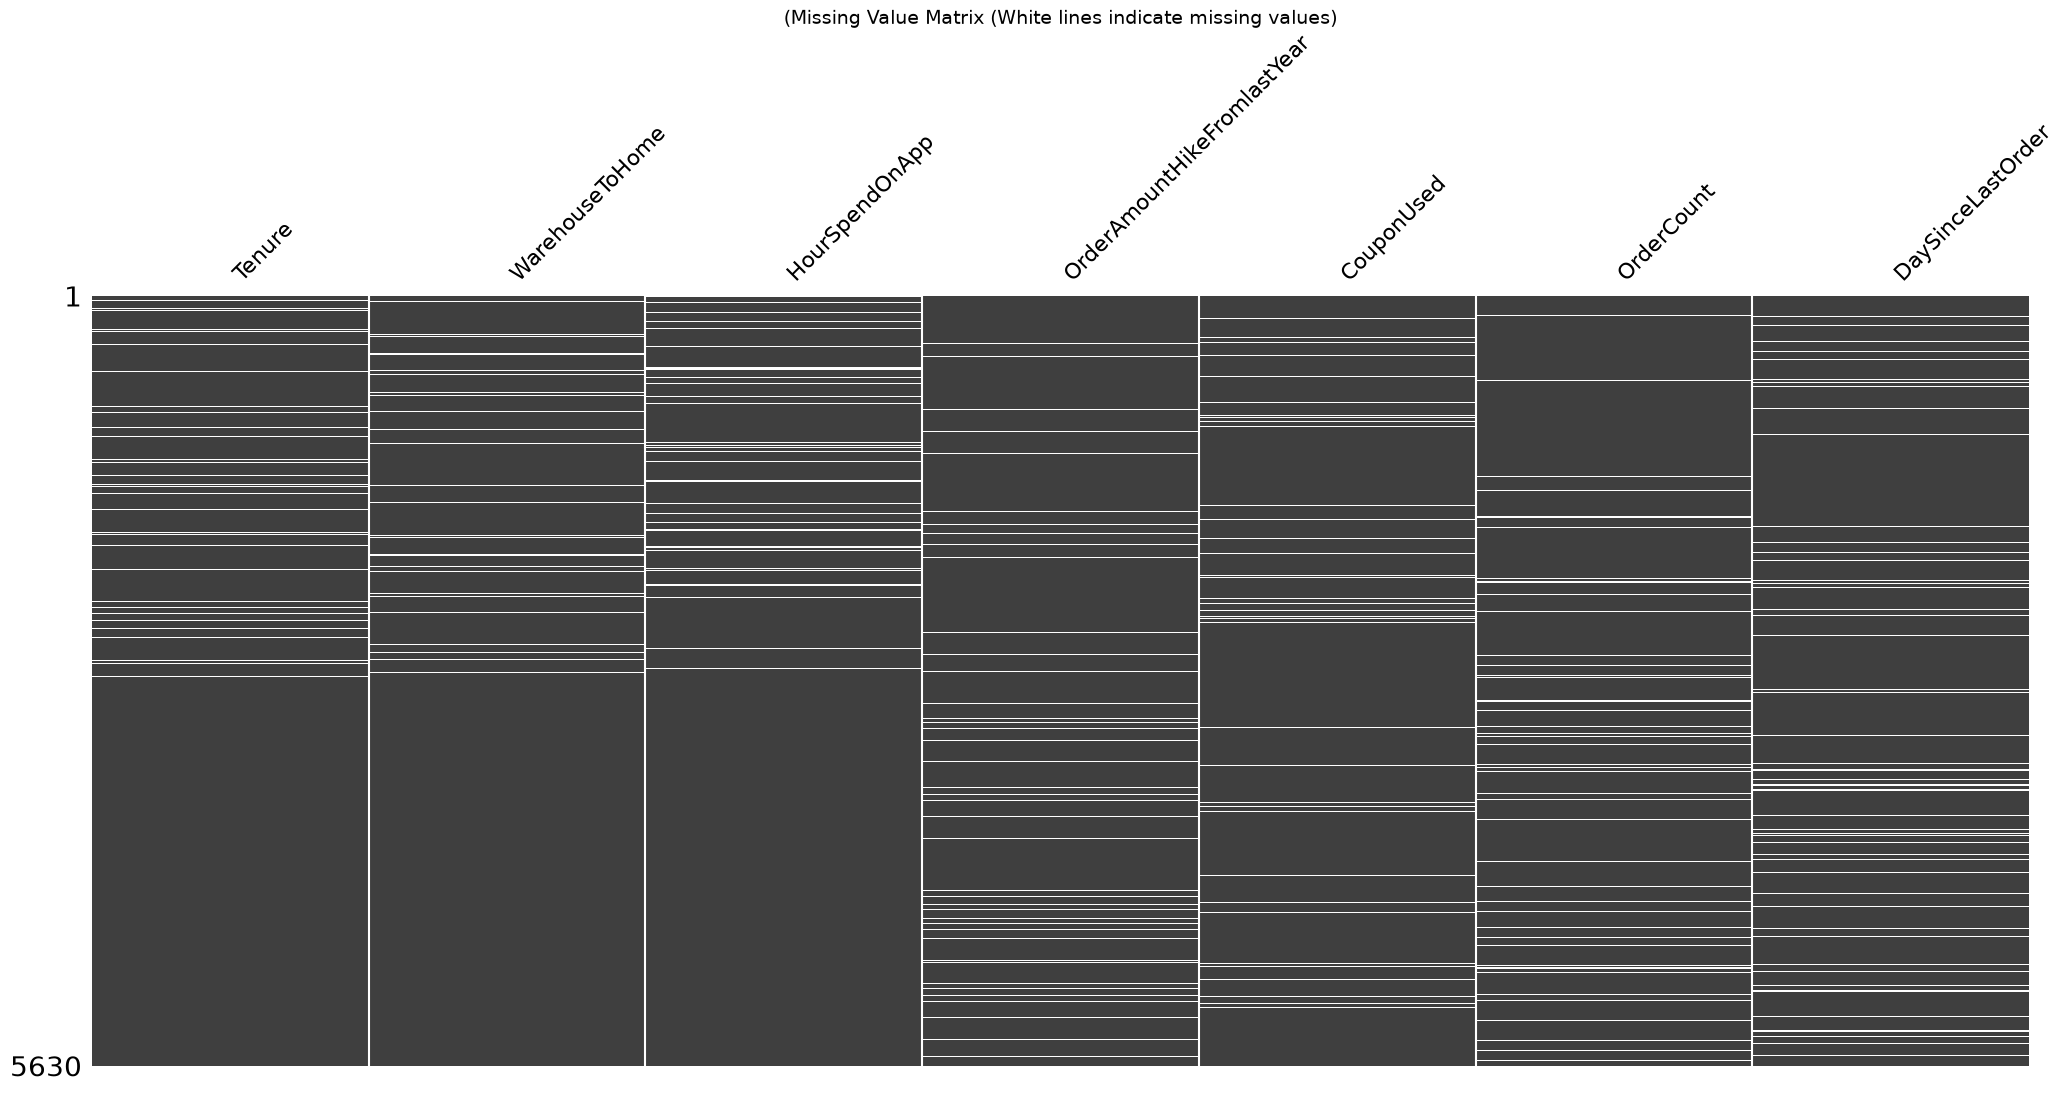

<Figure size 1600x1800 with 0 Axes>

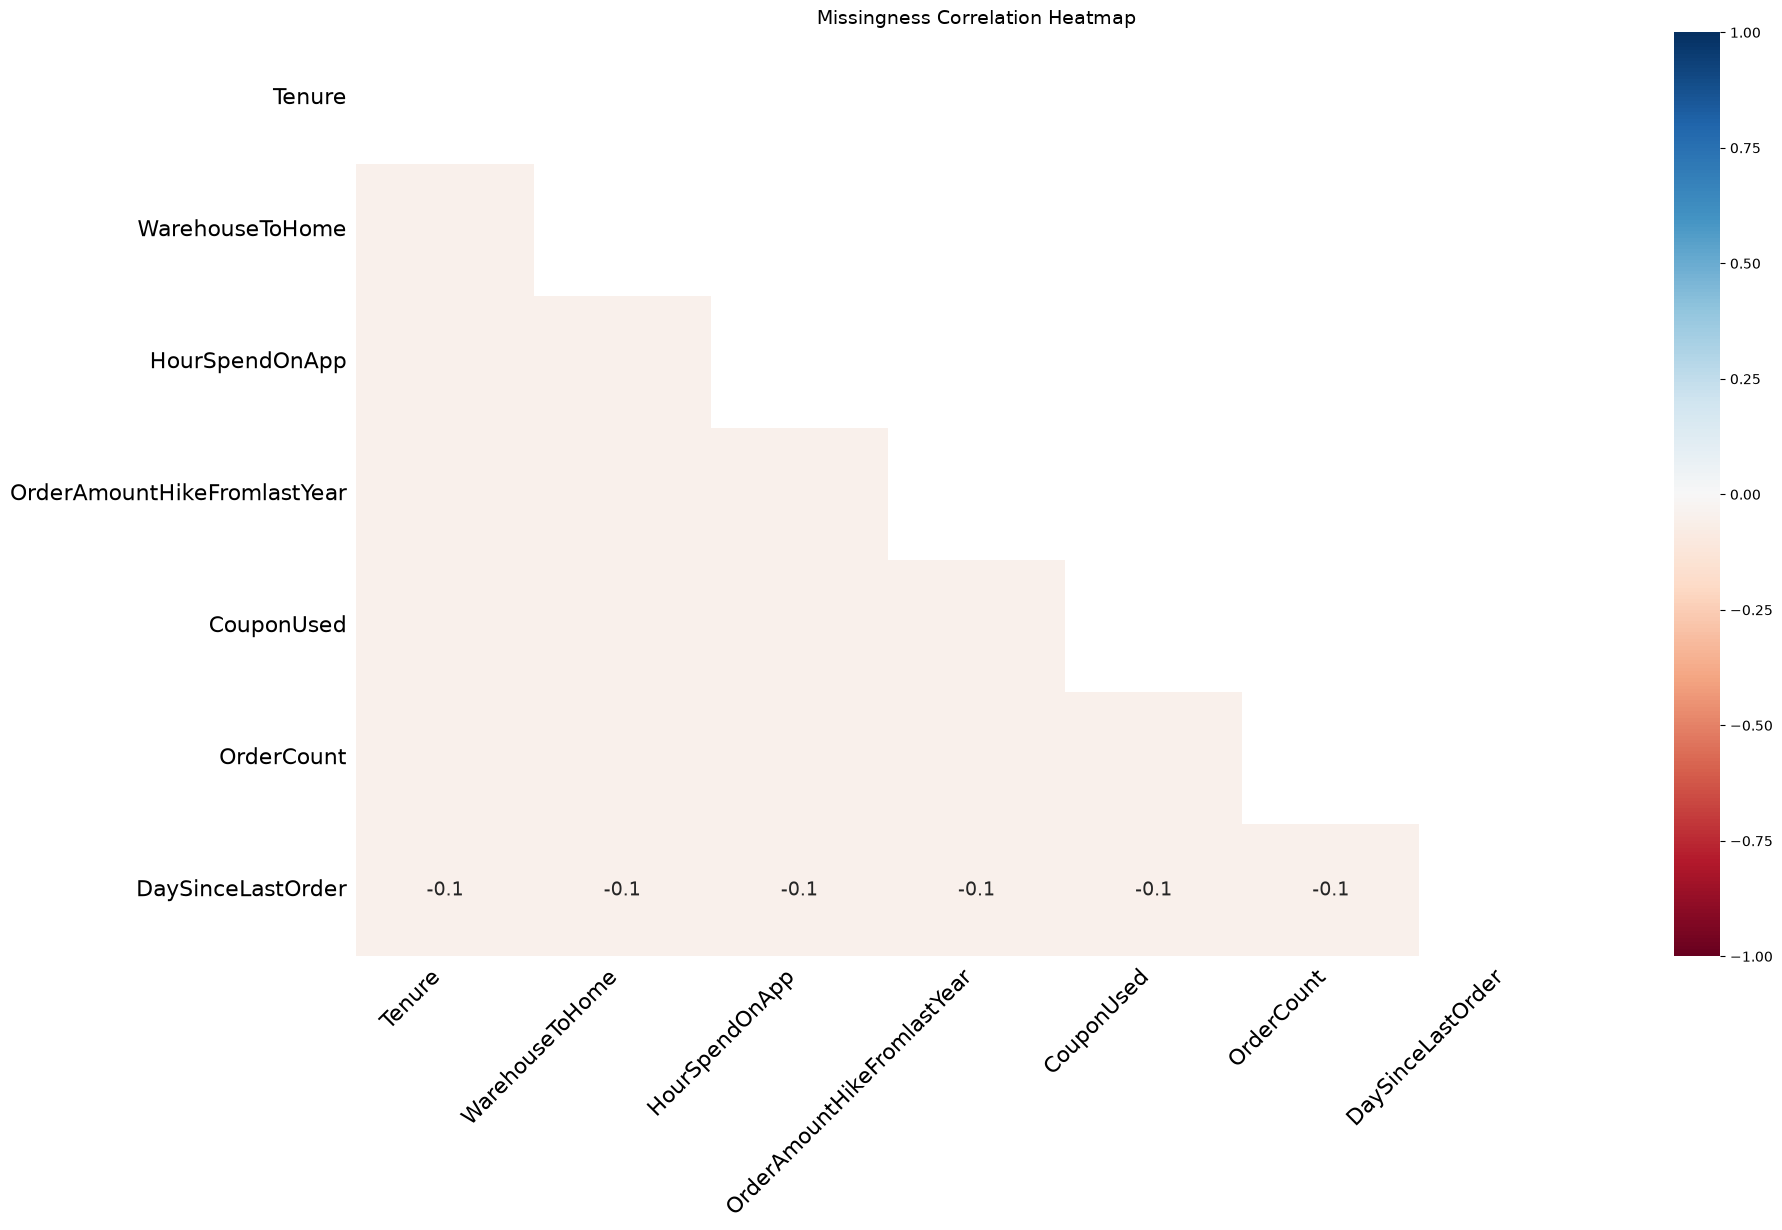

In [3]:
import missingno as msno
import matplotlib.pyplot as plt

df.isnull().sum()


missing_cols = ["Tenure","WarehouseToHome","HourSpendOnApp", "OrderAmountHikeFromlastYear","CouponUsed","OrderCount","DaySinceLastOrder"]

null_matrix = df[missing_cols].isnull().astype(int)
co_occurrence_matrix = null_matrix.T.dot(null_matrix)
print(co_occurrence_matrix, '\n', "=" * 100)
print(null_matrix.corr())

# Plotting Null Matrix
plt.figure(figsize=(10, 6))
msno.matrix(df[missing_cols], sparkline=False)
plt.title("(Missing Value Matrix (White lines indicate missing values)", fontsize=14)
plt.show()

# Heatmap to see correlation between missing values
plt.figure(figsize=(16, 18))
msno.heatmap(df[missing_cols])
plt.title("Missingness Correlation Heatmap", fontsize=14)
plt.show()

# Interpreting Results and Selecting Imputation Strategy

Understanding missing data patterns is critical for selecting the appropriate strategy. Evaluating co-occurrence and correlation metrics determines whether univariate or multivariate imputation is required.

---

## Scenario A: High Co-occurrence (High Correlation / Shared Rows)

### 1. Observation

* The `missing_per_row` metric reveals multiple rows with 3, 4, or 5 missing values simultaneously.
* Visualization via `msno.heatmap()` shows strong positive correlation (near +1.0) between features such as `CouponUsed` and `OrderCount`.

### 2. Implication

Missingness is structurally connected across features. For instance, customers who have placed 0 orders inherently record `NaN` for `CouponUsed` and `DaySinceLastOrder`.

### 3. Imputation Strategy

* **Structural Missingness:** Apply logical rule-based filling (e.g., set `OrderCount`, `CouponUsed`, and `DaySinceLastOrder` to 0 for non-ordering users).
* **Systemic Missingness:** Apply multivariate imputation tools such as MICE (`IterativeImputer`) or `KNNImputer` to leverage relationships between features.

### Python Implementation

```python
import numpy as np
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Step 1: Handle structural missingness with logical values
df["OrderCount"] = df["OrderCount"].fillna(0)
df.loc[df["OrderCount"] == 0, ["CouponUsed", "DaySinceLastOrder"]] = 0

# Step 2: Handle systemic missingness using MICE (IterativeImputer)
mice_imputer = IterativeImputer(random_state=42)
features_to_impute = ["Tenure", "CouponUsed", "DaySinceLastOrder"]
df[features_to_impute] = mice_imputer.fit_transform(df[features_to_impute])

```

---

## Scenario B: Low Co-occurrence / Independent Missingness

### 1. Observation

* The `missing_per_row` metric indicates that missingness is mostly isolated to 1 feature per row.
* Off-diagonal values in the `co_occurrence_matrix` remain near 0.

### 2. Implication

Missing values are scattered randomly across customer records without strong inter-feature dependency.

### 3. Imputation Strategy

* **Univariate Imputation:** Impute feature-by-feature independently.
* **Skewed Continuous Features:** Fill missing values using the column median (`Tenure`, `WarehouseToHome`, `DaySinceLastOrder`).
* **Discrete / Ordinal Features:** Fill missing values using the column median or mode (`HourSpendOnApp`, `OrderCount`).

### Python Implementation

```python
import pandas as pd

# Step 1: Univariate median imputation for skewed continuous features
continuous_cols = ["Tenure", "WarehouseToHome", "DaySinceLastOrder"]
for col in continuous_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Step 2: Univariate mode/median imputation for discrete or ordinal features
ordinal_cols = ["HourSpendOnApp", "OrderCount"]
for col in ordinal_cols:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

```
---

**Our co-occurrence and correlation values confirm Scenario B**

---

**Overall churn rate — how imbalanced is it?**

In [4]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

**Univariate: distributions of Tenure, WarehouseToHome, SatisfactionScore, CashbackAmount.**

            Tenure  WarehouseToHome  SatisfactionScore  CashbackAmount
count  5366.000000      5379.000000        5630.000000     5630.000000
mean     10.189899        15.639896           3.066785      177.223030
std       8.557241         8.531475           1.380194       49.207036
min       0.000000         5.000000           1.000000        0.000000
25%       2.000000         9.000000           2.000000      145.770000
50%       9.000000        14.000000           3.000000      163.280000
75%      16.000000        20.000000           4.000000      196.392500
max      61.000000       127.000000           5.000000      324.990000
==================Skew=====================
Tenure               0.736513
WarehouseToHome      1.619154
SatisfactionScore   -0.142626
CashbackAmount       1.149846
dtype: float64
==================Missing Values=========================
Tenure               264
WarehouseToHome      251
SatisfactionScore      0
CashbackAmount         0
dtype: int64
===========

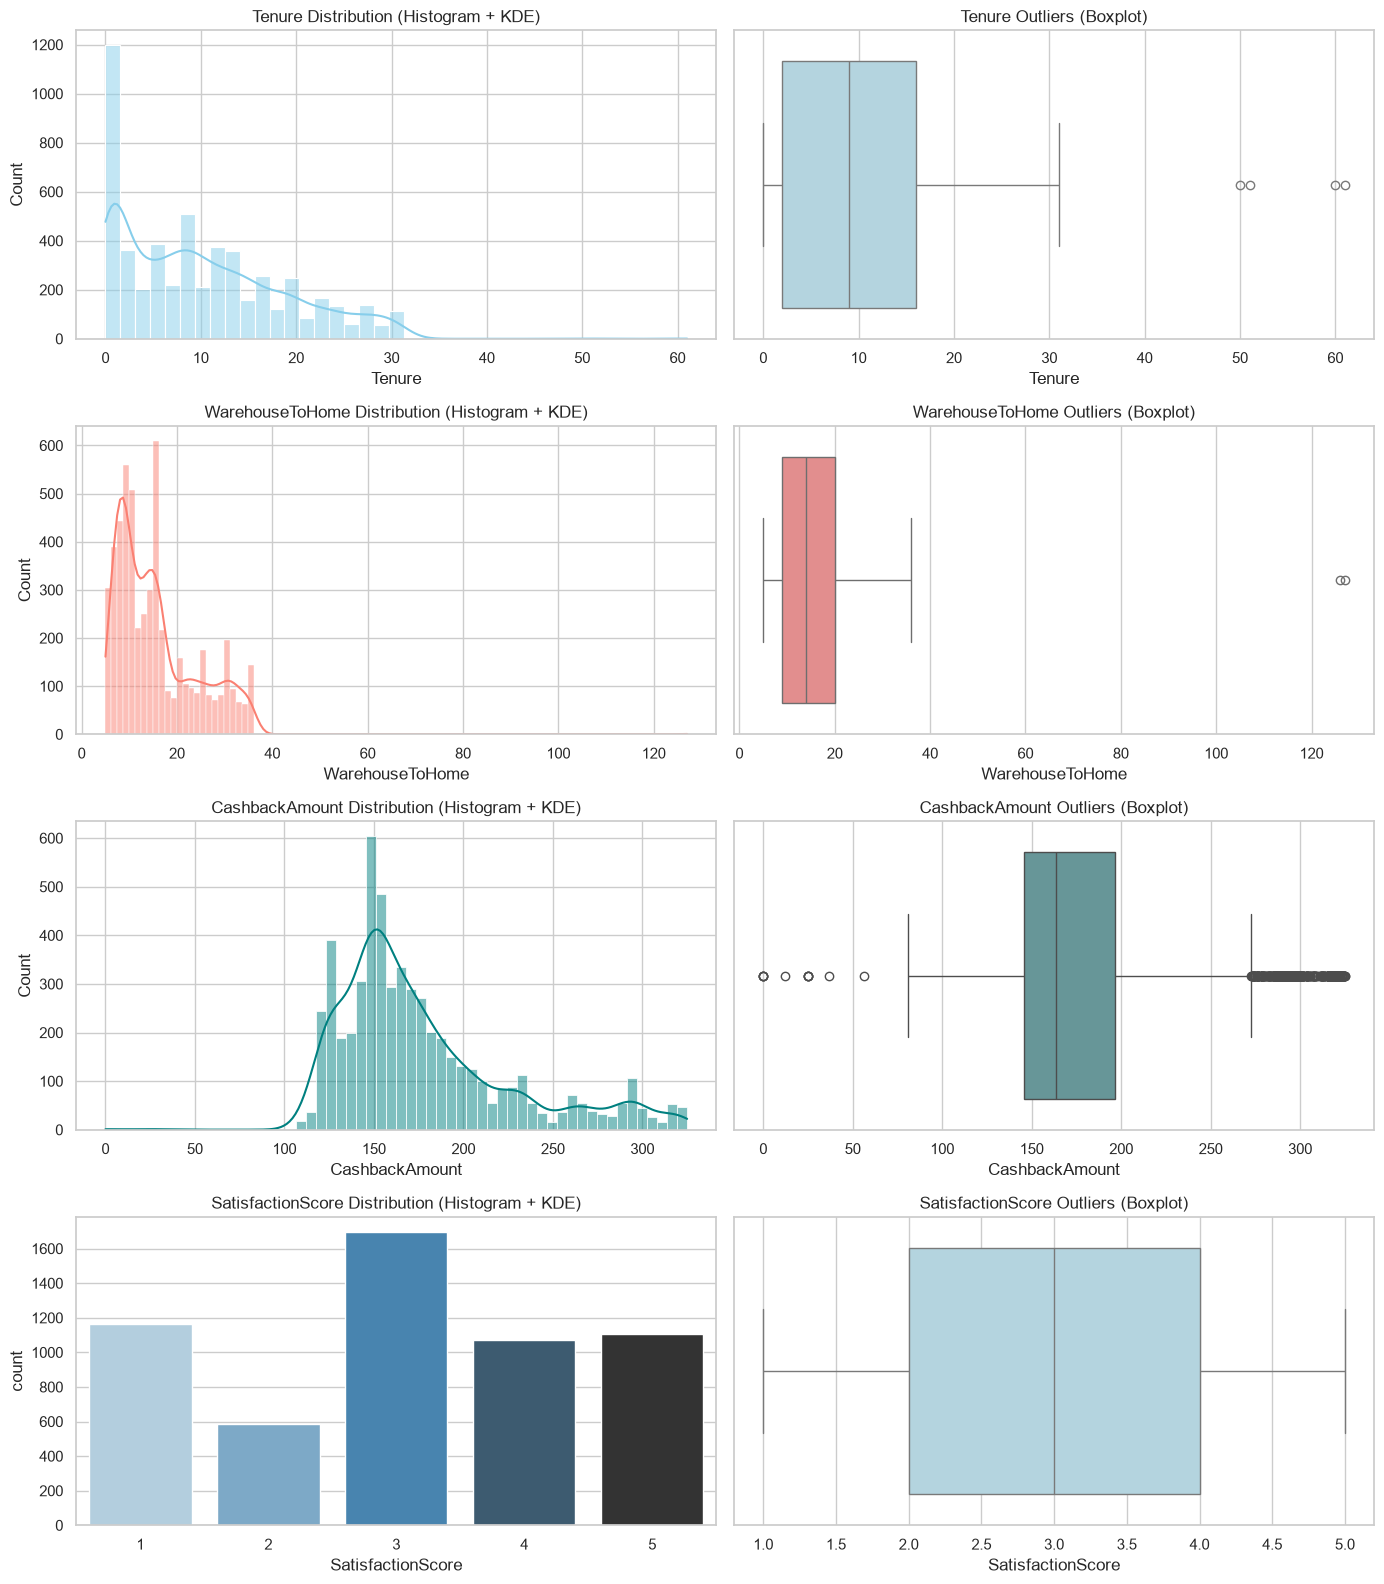

In [5]:
target_cols = ["Tenure", "WarehouseToHome", "SatisfactionScore", "CashbackAmount"]
print(df[target_cols].describe())

print("==================Skew=====================")
print(df[target_cols].skew())

print("==================Missing Values=========================")
print(df[target_cols].isnull().sum())

print("==================Plotting=======================================")
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

## 1 ---Tenure---
sns.histplot(df["Tenure"], kde=True, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Tenure Distribution (Histogram + KDE)")

sns.boxplot(x=df["Tenure"], ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Tenure Outliers (Boxplot)")

## 2 ---WarehouseToHome---
sns.histplot(df["WarehouseToHome"], kde=True, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("WarehouseToHome Distribution (Histogram + KDE)")

sns.boxplot(x=df["WarehouseToHome"], ax=axes[1, 1], color="lightcoral")
axes[1, 1].set_title("WarehouseToHome Outliers (Boxplot)")

## 3 ---CashbackAmount---
sns.histplot(df["CashbackAmount"], kde=True, ax=axes[2, 0], color="teal")
axes[2, 0].set_title("CashbackAmount Distribution (Histogram + KDE)")

sns.boxplot(x=df["CashbackAmount"], ax=axes[2, 1], color="cadetblue")
axes[2, 1].set_title("CashbackAmount Outliers (Boxplot)")

## 4 ---SatisfactionScore---
sns.countplot(x="SatisfactionScore", data=df, ax=axes[3, 0], palette="Blues_d", hue="SatisfactionScore", legend=False)
axes[3, 0].set_title("SatisfactionScore Distribution (Histogram + KDE)")

sns.boxplot(x=df["SatisfactionScore"], ax=axes[3, 1], color="lightblue")
axes[3, 1].set_title("SatisfactionScore Outliers (Boxplot)")

plt.tight_layout()
plt.show()

**Bivariate vs. churn: CityTier, PreferredLoginDevice, MaritalStatus, Complain, PreferredPaymentMode.**

In [6]:
print(df["PreferredLoginDevice"].value_counts())
print(df["PreferredPaymentMode"].value_counts())
print("="*150)

df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({"Mobile Phone": "Phone"})
df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({"CC": "Credit Card", "COD": "Cash on Delivery"})
df["PreferredPaymentMode"].value_counts()

target_cols = ["CityTier", "PreferredLoginDevice", "MaritalStatus", "Complain", "PreferredPaymentMode"]
    
overall_churn_rate = df["Churn"].mean()
total_churn = df["Churn"].sum()
ranked_summary = []

for col in target_cols:
    bivariate = df.groupby(col)["Churn"].agg(
        Total_Customer="count",
        Churned_Customers="sum",
        Group_Churn_Rate="mean"
    ).reset_index()
    
    bivariate["vs_Overall_Churn_Rate"] = bivariate["Group_Churn_Rate"] / overall_churn_rate
    
    low_in_group = bivariate["Group_Churn_Rate"].min()
    bivariate["vs_low_in_group"] = bivariate["Group_Churn_Rate"] / low_in_group

    # Measure the impact of this group in total churn
    bivariate["Share_Of_Total_Churn"] = bivariate["Churned_Customers"] / total_churn

    bivariate["feature_name"] = col
    bivariate.rename(columns={col: "category_value"}, inplace=True)
    
    ranked_summary.append(bivariate)


summary_df = pd.concat(ranked_summary, ignore_index=True)

# Format columns for display
summary_df["Group_Churn_Rate_Pct"] = (summary_df["Group_Churn_Rate"] * 100).round(2)
summary_df["Share_Of_Total_Churn_Pct"] = (summary_df["Share_Of_Total_Churn"] * 100).round(2)
summary_df["vs_Overall_Churn_Rate"] = summary_df["vs_Overall_Churn_Rate"].round(2)
summary_df["vs_low_in_group"] = summary_df["vs_low_in_group"].round(2)

# Reorder columns logically
final_columns = [
    "feature_name",
    "category_value",
    "Total_Customer",
    "Churned_Customers",
    "Group_Churn_Rate_Pct",
    "vs_low_in_group",
    "vs_Overall_Churn_Rate",
    "Share_Of_Total_Churn_Pct"
]

summary_df = summary_df[final_columns].sort_values(by="vs_low_in_group", ascending=False)
print(f"Total Churned Population: {total_churn}")
print(summary_df.to_string(index=False))
    

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Total Churned Population: 948
        feature_name   category_value  Total_Customer  Churned_Customers  Group_Churn_Rate_Pct  vs_low_in_group  vs_Overall_Churn_Rate  Share_Of_Total_Churn_Pct
            Complain                1            1604                508                 31.67             2.90                   1.88                     53.59
       MaritalStatus           Single            1796                480                 26.73             2.32                   1.59                     50.63
PreferredPaymentMode Cash on Delivery             514                128                 24.90             1.75                   1.48                     

0    14.511729
1    19.834711
2    21.370499
Name: Churned_Pct, dtype: float64
0    19.828641
1    15.615616
Name: Churned_Pct, dtype: float64
0    14.622642
1    11.520429
2    26.726058
Name: Churned_Pct, dtype: float64
0    10.928962
1    31.670823
Name: Churned_Pct, dtype: float64
0    24.902724
1    14.205186
2    15.384615
3    22.801303
4    17.391304
Name: Churned_Pct, dtype: float64


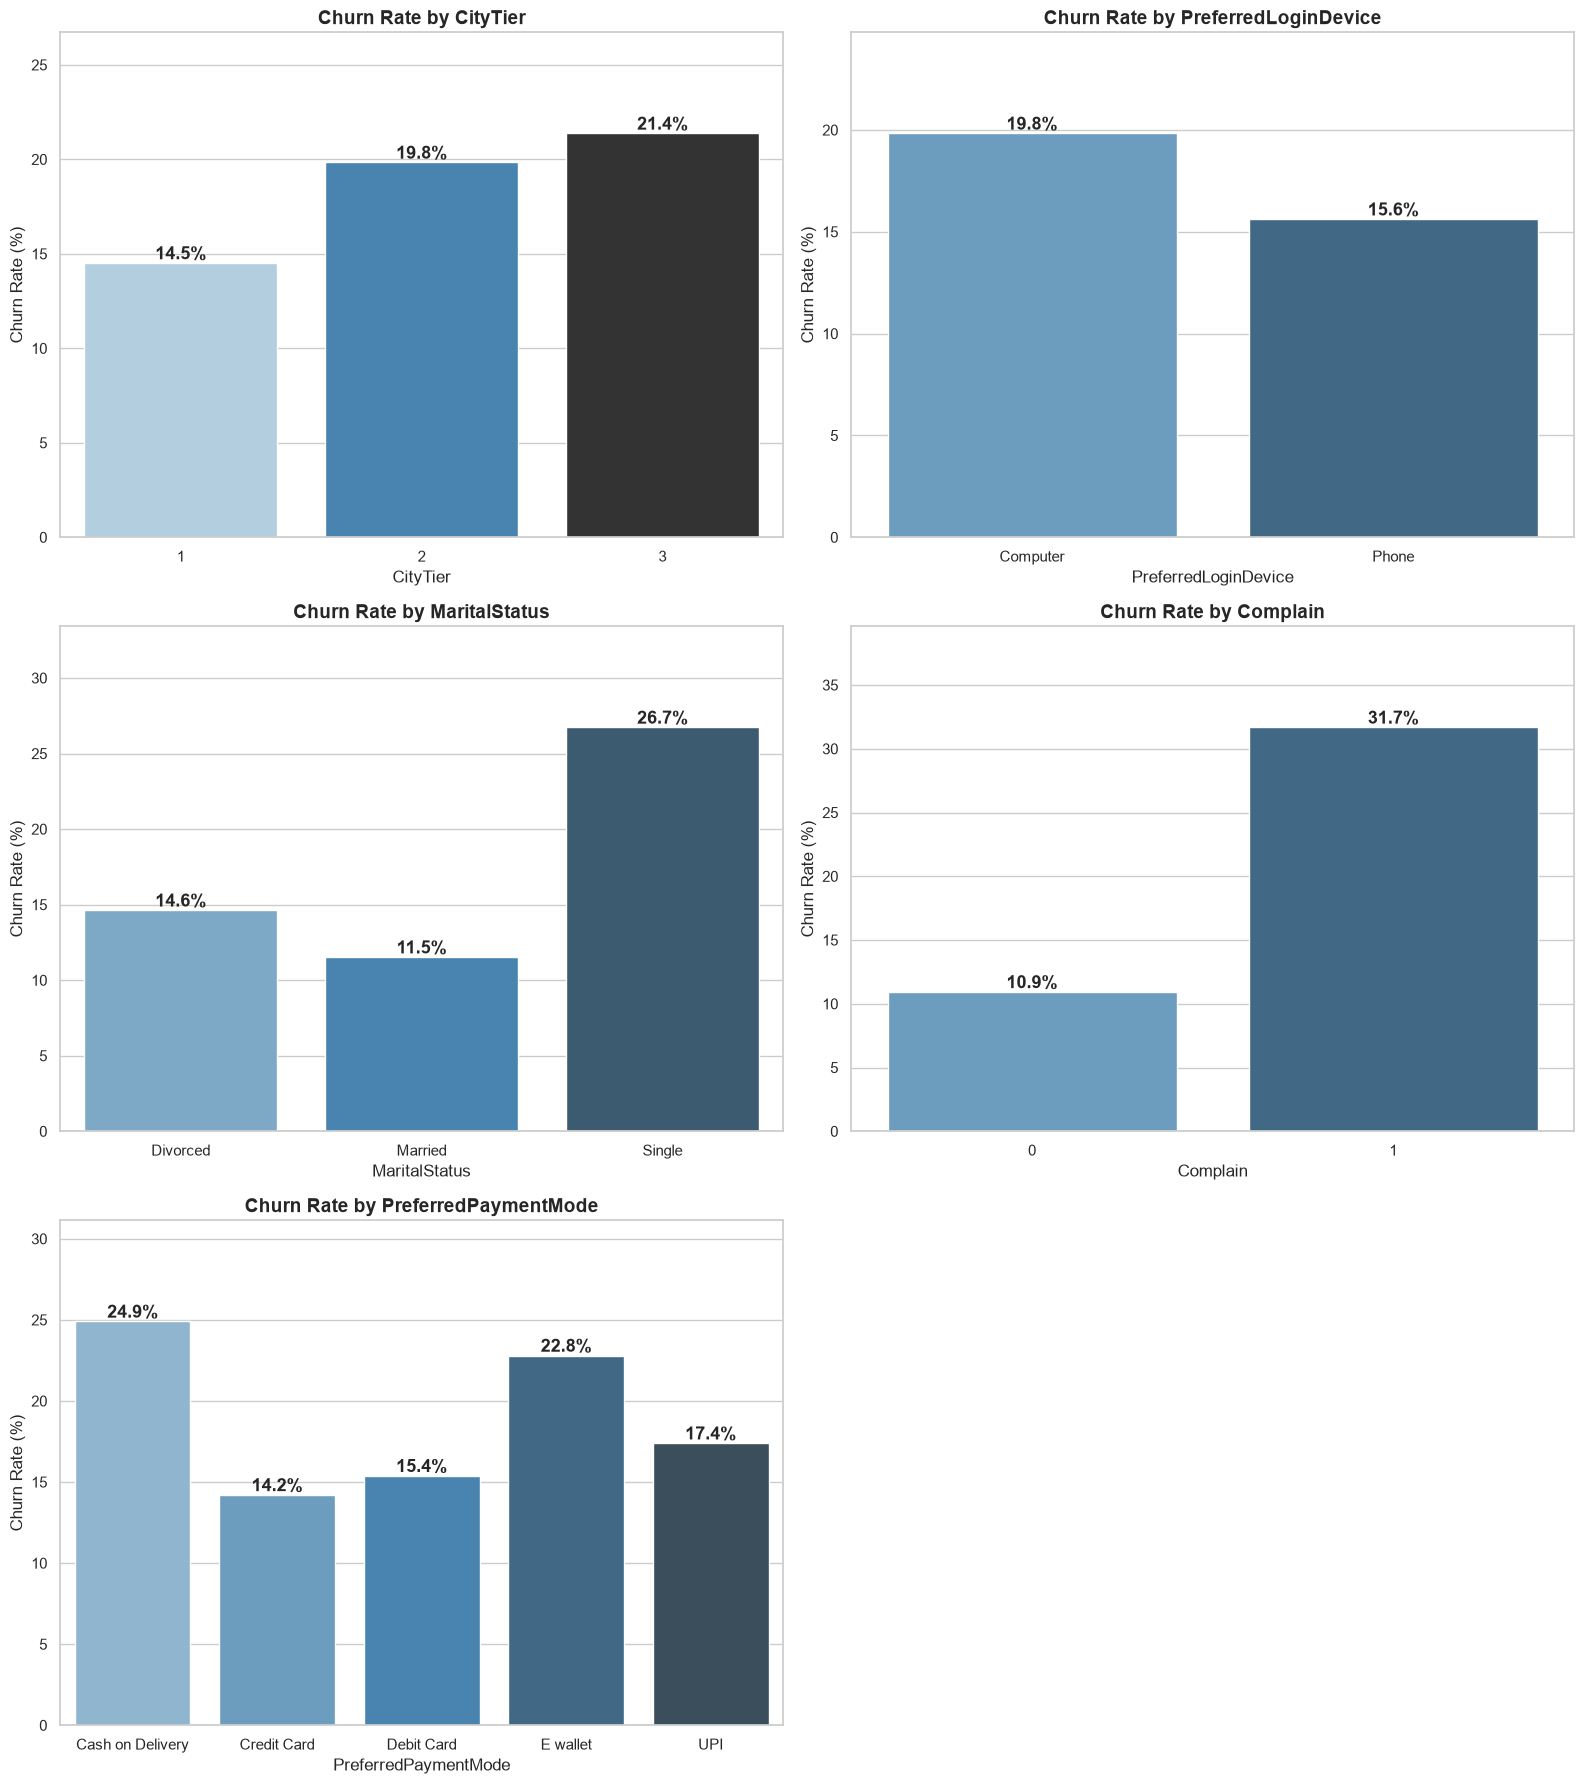

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(target_cols):
    data = df.groupby(col)["Churn"].mean().reset_index()
    data["Churned_Pct"] = data["Churn"] * 100
    print(data["Churned_Pct"].head(5))
    
    ax = axes[idx]
    sns.barplot(
        data=data,
        x=col,
        y="Churned_Pct",
        ax=ax,
        palette="Blues_d",
        hue=col,
        legend=False
    )  
    
    ax.set_title(f"Churn Rate by {col}", fontsize=14, fontweight="bold")  
    ax.set_ylabel(f"Churn Rate (%)", fontsize=12)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylim(0, max(data["Churned_Pct"]) * 1.25)
    
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold"
        )
        
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**Correlation heatmap for numeric features.**

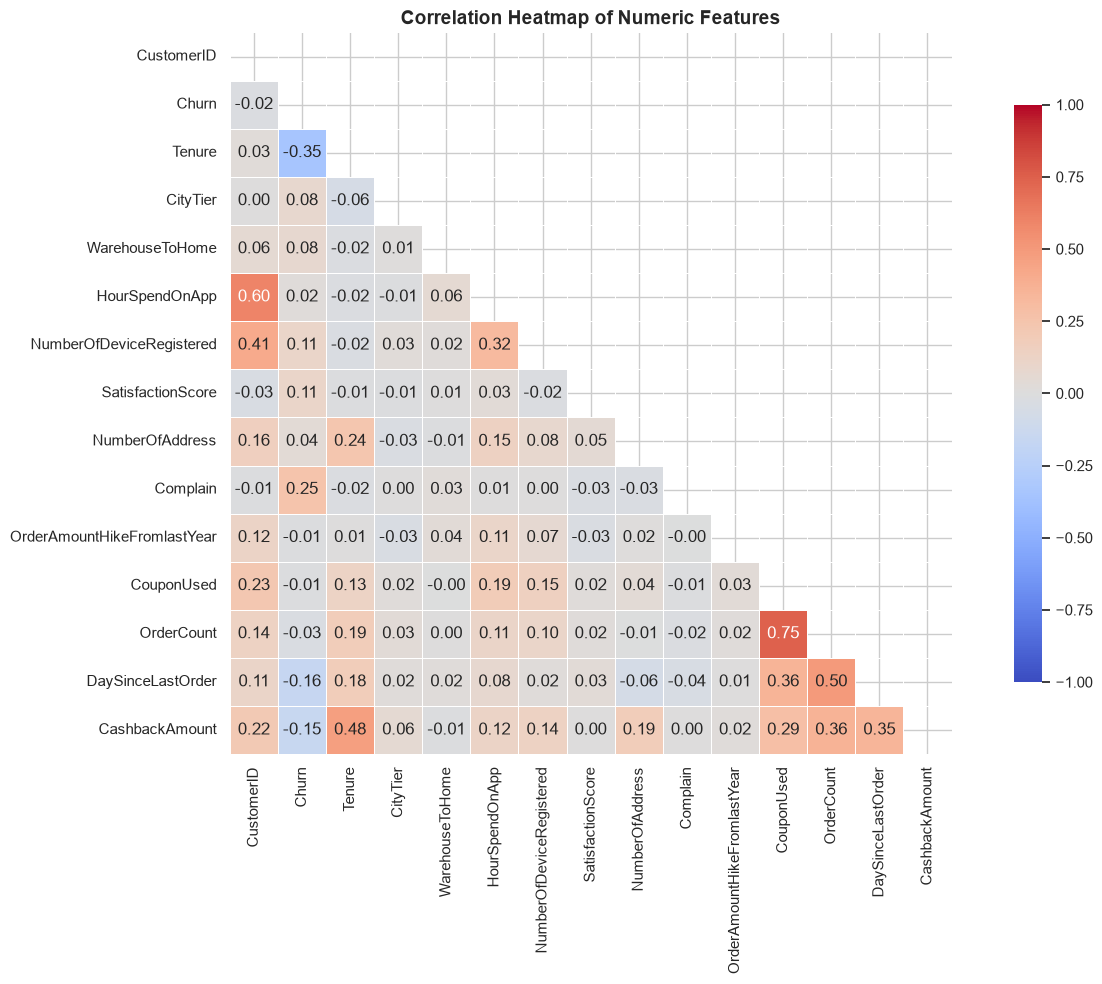

In [8]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))

sns.heatmap(
    data=corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

**My findings:**

1- The customers that complains are more likely to churn than the customers the didn't by 2.9 times and it 1.88 times the overall churn so it need immediate thinking and direct intervention cause it have 53% of of total churned customer

2- Operational fixes, direct interventions, immediate process changes needed for single customers cause 50% of total churned customer are singles and they have rate of 2.32 compared to married and 1.59 more than overall churn rate   

3- The third most likely to churn flag is CashOnDelivery they are 24.90% likely to churn, and they are 1.48x rate of overall churn rate, but they dont represent large group of churned customers with 13.5% of total churned customers cause we have lots if payment types 

---









---

##  Cleaning & feature engineering

### Handle missing values per-column (not a blanket dropna()) — one sentence justifying each choice.

since we already knew that our data missing cols are not correlated to each other so we well fill the missed values with mean for continuos skewed cols and mode for ordinal and discrete columns.

(im not really sure about my classification of continuois and ordinal columns cause i do if the column have more than 10
 unique values he is discerte and if it have more than 20 unique it continuos i want u to tell how to classify between them)

In [9]:
continuos_cols = ["Tenure", "WarehouseToHome", "OrderAmountHikeFromlastYear", "CouponUsed", "DaySinceLastOrder"]
ordinal_cols = ["HourSpendOnApp", "OrderCount"]

print(df.columns)
for col in continuos_cols:
    if df[col].skew() > 1.0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
    else: 
        mean_val = df[col].mean()
        df[col] = df[col].fillna(mean_val)
        
for col in ordinal_cols:
    mode_val = df[col].mode()
    df[col] = df[col].fillna(mode_val)

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')


### Encode categoricals (CityTier is ordinal, PreferredLoginDevice isn't — treat them differently).

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["PreferredLoginDevice", "PreferredPaymentMode", "Gender", "PreferedOrderCat", "MaritalStatus"]

df2 = df
df2.columns = [str(col) for col in df2.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", sparse_output=False), cat_cols)
    ], remainder="passthrough", verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")

transformed_data = preprocessor.fit_transform(df2)

encoded_col_names = preprocessor.get_feature_names_out()
df_processed = pd.DataFrame(transformed_data, columns=encoded_col_names)
df_processed.columns = df_processed.columns.str.replace(r"^.*__", "", regex=True)
print(df_processed.to_string())



      PreferredLoginDevice_Phone  PreferredPaymentMode_Credit Card  PreferredPaymentMode_Debit Card  PreferredPaymentMode_E wallet  PreferredPaymentMode_UPI  Gender_Male  PreferedOrderCat_Grocery  PreferedOrderCat_Laptop & Accessory  PreferedOrderCat_Mobile  PreferedOrderCat_Mobile Phone  PreferedOrderCat_Others  MaritalStatus_Married  MaritalStatus_Single  CustomerID  Churn     Tenure  CityTier  WarehouseToHome  HourSpendOnApp  NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  OrderAmountHikeFromlastYear  CouponUsed  OrderCount  DaySinceLastOrder  CashbackAmount
0                            1.0                               0.0                              1.0                            0.0                       0.0          0.0                       0.0                                  1.0                      0.0                            0.0                      0.0                    0.0                   1.0       50001      1   4.000000         3          

###  Engineer at least 2 new features not in the raw data (e.g. a "recent complaint + short tenure" risk flag, or a cashback-to-order ratio). Most tutorials skip this — it's a differentiator.

In [ ]:
analysis_df = df.copy()

analysis_df["ShortTenure_Complain_Flag"] = ((analysis_df["Tenure"] <= 3) & (analysis_df["Complain"] == 1)).astype(int)
analysis_df["Cashback_Per_Order"] = analysis_df["CashbackAmount"] / (analysis_df["OrderCount"] + 1)
analysis_df["Order_Velocity"] = analysis_df["OrderCount"] / (analysis_df["Tenure"] + 1)
analysis_df["Order_Velocity"] = analysis_df["Order_Velocity"].round(2)

print(analysis_df.head())

   CustomerID  Churn     Tenure PreferredLoginDevice  CityTier  \
0       50001      1   4.000000                Phone         3   
1       50002      1  10.189899                Phone         1   
2       50003      1  10.189899                Phone         1   
3       50004      1   0.000000                Phone         3   
4       50005      1   0.000000                Phone         1   

   WarehouseToHome PreferredPaymentMode  Gender  HourSpendOnApp  \
0              6.0           Debit Card  Female             3.0   
1              8.0                  UPI    Male             3.0   
2             30.0           Debit Card    Male             2.0   
3             15.0           Debit Card    Male             2.0   
4             12.0          Credit Card    Male             NaN   

   NumberOfDeviceRegistered  ... NumberOfAddress  Complain  \
0                         3  ...               9         1   
1                         4  ...               7         1   
2             

### Machine Learning Approach fot data preprocessing
i have done it inside a pipeline to prevent data leakage, (u can rate this approach if u don't agree tell me no problem)

In [11]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


class EcommerceFeatureEngineering(BaseEstimator, TransformerMixin):
    
    def __init__(self, tenure_threshold=3):
        self.tenure_threshold = tenure_threshold
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_out = X.copy()
        
        X_out["ShortTenure_Complain_Flag"] = (
            (X_out["Tenure"] <= self.tenure_threshold) & (X_out["Complain"] == 1)
        ).astype(int)
        
        X_out["Cashback_Per_Order"] = X_out["CashbackAmount"] / (X_out["OrderCount"] + 1)
        
        X_out["Order_velocity"] = X_out["OrderCount"] / (X_out["Tenure"] + 1)
    
        return X_out
    
    
class CategoricalCleaner(BaseEstimator, TransformerMixin):
    
    def __init__(self, replacement_map):
        self.replacement_map = replacement_map
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_out = X.copy()
        
        if self.replacement_map:
            for col, mapping in self.replacement_map.items():
                if col in X_out.columns:
                    X_out[col] = X_out[col].replace(mapping)
                              
        return X_out
    
    
replacement_map = {
    "PreferedOrderCat": {
        "Mobile": "Mobile Phone"
    }
}

X = df.drop(columns=["Churn", "CustomerID"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_cols = [col for col in X.columns if col not in cat_cols]
engineered_num_cols = num_cols + ["ShortTenure_Complain_Flag", "Cashback_Per_Order", "Order_velocity"]

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipline = Pipeline([
    ("onehot", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, engineered_num_cols),
        ("cat", cat_pipline, cat_cols)
    ],
    verbose_feature_names_out=False
)
preprocessor.set_output(transform="pandas")

full_preprocessing_pipeline = Pipeline([
    ("cleaner", CategoricalCleaner(replacement_map=replacement_map)),
    ("feature_engineering", EcommerceFeatureEngineering(tenure_threshold=3)),
    ("preprocessor", preprocessor)
])

X_train_processed = full_preprocessing_pipeline.fit_transform(X_train)
X_test_processed = full_preprocessing_pipeline.transform(X_test)

print(X_train_processed)






        Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
1787 -0.142204  1.453559         0.043177       -1.292560   
2147 -0.501728  1.453559        -0.318966       -2.678434   
1717 -0.262045 -0.724000        -0.077537        0.093314   
2292  0.576844  1.453559        -0.560394        0.093314   
5578  0.217320 -0.724000        -0.318966        1.479188   
...        ...       ...              ...             ...   
4066  0.217320 -0.724000         0.043177        1.479188   
4563  0.576844  1.453559        -1.043252        0.093314   
4770 -1.100934 -0.724000        -0.439680        0.093314   
1384 -0.501728  1.453559        -1.163966       -1.292560   
5140 -1.100934  1.453559        -0.801823        0.093314   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
1787                 -0.675976          -1.493573        -0.856755 -0.623912   
2147                 -0.675976           0.673881        -1.246653 -0.623912   
1717                  0.294

###  Stratified train/test split (the data's imbalanced).
for imbalanced dataset like our we must keep the ratio of the churned data and non-churned data so when we split data the ratio must be
same for both train and test splits, and since i already stratify the splits i need just to check if the ratios inside each split is the same

In [12]:
print(X_train_processed.shape, X_test_processed.shape)


distribution_summary = pd.DataFrame({
    "Original Data": y.value_counts(normalize=True),
    "Train set (y_train)": y_train.value_counts(normalize=True),
    "Test set (y_test)": y_test.value_counts(normalize=True)
})

distribution_summary = distribution_summary * 100
print(distribution_summary.round(2))

(4504, 28) (1126, 28)
       Original Data  Train set (y_train)  Test set (y_test)
Churn                                                       
0              83.16                83.17              83.13
1              16.84                16.83              16.87
